# 01 KAN Basics

This is a notebook with the KAN basic implementation based on the base paper of KANs (https://arxiv.org/abs/2404.19756)

In [11]:
import torch
from kan import KAN, create_dataset
import matplotlib.pyplot as plt

## Define a target function and create a dataset

In [12]:
f = lambda x: torch.exp(torch.sin(torch.pi * x[:, [0]]) + x[:, [1]] ** 2)

dataset = create_dataset(f, n_var=2, train_num=1000, test_num=1000, ranges=[-1, 1])

print(f"Train input shape: {dataset['train_input'].shape}")
print(f"Train label shape: {dataset['train_label'].shape}")

Train input shape: torch.Size([1000, 2])
Train label shape: torch.Size([1000, 1])


## Create and inspect a KAN

In [13]:
model = KAN(width=[2, 5, 1], grid=5, k=3, seed=42, auto_save=False)

n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params}")

Number of parameters: 348


## Train the KAN

In [14]:
results = model.fit(dataset, opt="LBFGS", steps=50, lr=1.0, lamb=0.001)

| train_loss: 9.34e-03 | test_loss: 1.00e-02 | reg: 8.80e+00 | : 100%|█| 50/50 [00:05<00:00,  8.82it


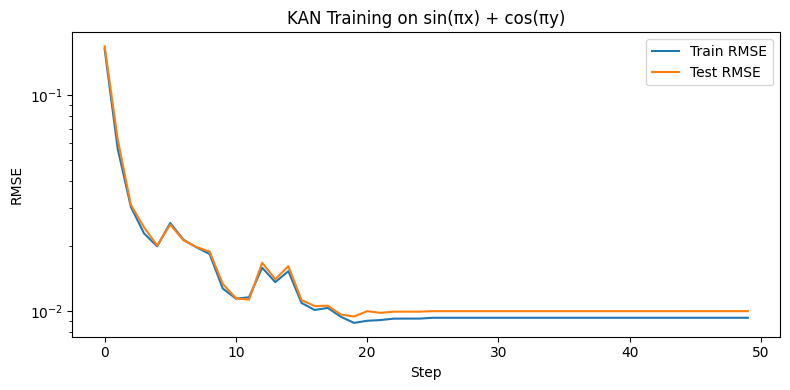

In [15]:
# Plot loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results["train_loss"], label="Train RMSE")
ax.plot(results["test_loss"], label="Test RMSE")
ax.set_xlabel("Step")
ax.set_ylabel("RMSE")
ax.set_yscale("log")
ax.legend()
ax.set_title("KAN Training on sin(πx) + cos(πy)")
plt.tight_layout()
plt.show()

## Visualize learned activation functions

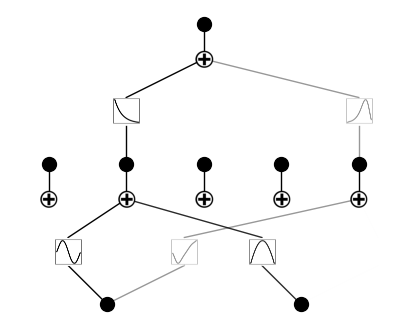

In [16]:
model.plot()

## Experiment: Effect of grid size

In [17]:
grid_sizes = [3, 5, 10, 20]
grid_results = {}

for g in grid_sizes:
    m = KAN(width=[2, 5, 1], grid=g, k=3, seed=42, auto_save=False)
    res = m.fit(dataset, opt="LBFGS", steps=50, lr=1.0, lamb=0.001)
    grid_results[g] = res
    print(f"Grid {g:2d}: final test RMSE = {res['test_loss'][-1]:.6f}")

| train_loss: 1.79e-02 | test_loss: 1.87e-02 | reg: 7.48e+00 | : 100%|█| 50/50 [00:06<00:00,  7.50it


Grid  3: final test RMSE = 0.018683


| train_loss: 9.34e-03 | test_loss: 1.00e-02 | reg: 8.80e+00 | : 100%|█| 50/50 [00:05<00:00,  9.88it


Grid  5: final test RMSE = 0.010019


| train_loss: 8.13e-03 | test_loss: 9.59e-03 | reg: 7.04e+00 | : 100%|█| 50/50 [00:07<00:00,  6.38it


Grid 10: final test RMSE = 0.009592


| train_loss: 3.54e-02 | test_loss: 8.33e-02 | reg: 1.43e+01 | : 100%|█| 50/50 [00:10<00:00,  4.58it

Grid 20: final test RMSE = 0.083264


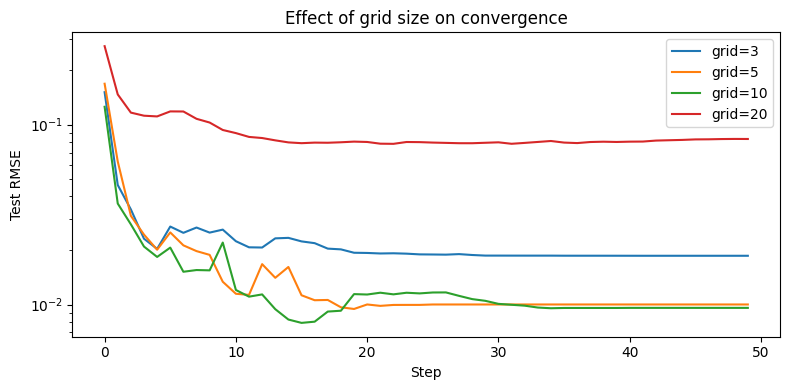

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
for g, res in grid_results.items():
    ax.plot(res["test_loss"], label=f"grid={g}")
ax.set_xlabel("Step")
ax.set_ylabel("Test RMSE")
ax.set_yscale("log")
ax.legend()
ax.set_title("Effect of grid size on convergence")
plt.tight_layout()
plt.show()

## Experiment: Effect of network width

In [19]:
widths = [[2, 3, 1], [2, 5, 1], [2, 10, 1], [2, 5, 5, 1]]
width_results = {}

for w in widths:
    m = KAN(width=w, grid=5, k=3, seed=42, auto_save=False)
    n_p = sum(p.numel() for p in m.parameters())
    res = m.fit(dataset, opt="LBFGS", steps=50, lr=1.0, lamb=0.001)
    width_results[str(w)] = res
    print(f"Width {str(w):16s} ({n_p:5d} params): final test RMSE = {res['test_loss'][-1]:.6f}")

| train_loss: 1.20e-02 | test_loss: 1.16e-02 | reg: 1.02e+01 | : 100%|█| 50/50 [00:04<00:00, 10.27it


Width [[2, 0], [3, 0], [1, 0]] (  220 params): final test RMSE = 0.011588


| train_loss: 9.34e-03 | test_loss: 1.00e-02 | reg: 8.80e+00 | : 100%|█| 50/50 [00:05<00:00,  9.14it


Width [[2, 0], [5, 0], [1, 0]] (  348 params): final test RMSE = 0.010019


| train_loss: 9.00e-03 | test_loss: 8.99e-03 | reg: 6.42e+00 | : 100%|█| 50/50 [00:10<00:00,  4.86it


Width [[2, 0], [10, 0], [1, 0]] (  668 params): final test RMSE = 0.008994


| train_loss: 1.27e-02 | test_loss: 1.22e-02 | reg: 9.26e+00 | : 100%|█| 50/50 [00:14<00:00,  3.52it

Width [[2, 0], [5, 0], [5, 0], [1, 0]] (  828 params): final test RMSE = 0.012249


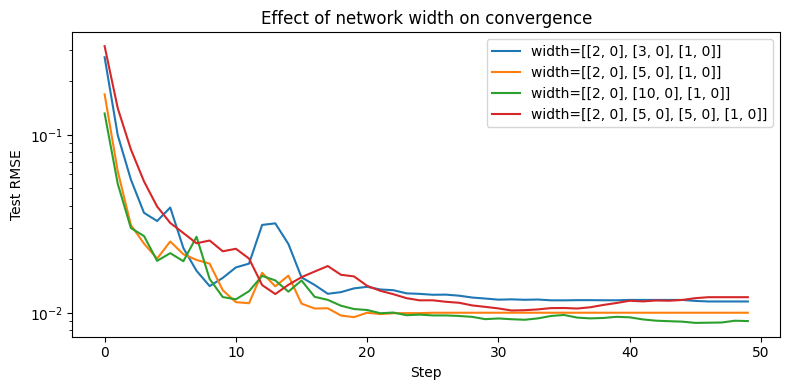

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
for w_str, res in width_results.items():
    ax.plot(res["test_loss"], label=f"width={w_str}")
ax.set_xlabel("Step")
ax.set_ylabel("Test RMSE")
ax.set_yscale("log")
ax.legend()
ax.set_title("Effect of network width on convergence")
plt.tight_layout()
plt.show()